In [2]:
%load_ext autoreload
%autoreload 2

from behave_analysis.analyze.behaviour.homings_escapes.homings_add_to_video_df import load_homing_for_aefizz
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from behave_analysis.utils.data_loading import load_or_extract_escapes
from behave_analysis.process.process import Process
from settings.settings_overrides import settings_overrides
from settings.settings_analyze_efizz import Settings_ae
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

import numpy as np
import os

%matplotlib inline

tuning_settings = {'ep_bins': 25,
                    'ep_no_stationary': False,
                    'ep_interpolation_mult': 2,
                    'ep_gaussian_fitting': False,
                    'ep_compute_loo_reliability': False,
                    'ep_tuned_compare_method': 'euclidean',
                    'ep_tuned_stats': 'bootstrap',
                    'ep_tuned_stats_samples': 100,
                    'linshift_min_step': 120,
                    'linshift_step': 80,
                    'linshift_step_n': 100,
                    'stim_type': 'audio',
                    'cluster_type': 'good',
                    'cluster_labels': "bombcell",
                    "homings": 'auto',
                    'condition_types': 'experimental_conditions',
                    'compartment_split': ['all'],
                    'redo_compute': False}
Settings_ae = settings_overrides(Settings_ae, tuning_settings)

h_settings = {"homings_speed_threshold": 4.0,  # cm/s, used to find bouts of running that may be homings
            "homings_gap_tolerance": 1,  # frames, used to merge bouts
            "homings_features_initial_window_s": 1.0,  # seconds, used to compute initial features of homings like acceleration and hdir change
            "homing_classification_target_recall": 0.9,  # minimum recall for a gate to be considered valid
            "homings_classification_recall_threshold": 0.9,  # minimum recall for a feature gate to be considered valid
            "homings_classification_precision_threshold": 0.1,  # minimum precision for a feature gate to be considered valid
            "homings_classification_auc_threshold": 0.9,  # or .8, minimum AUC for a feature gate to be considered valid
            "homings_classification_cohens_d_threshold": 1,  # minimum absolute Cohen's d for a feature gate to be considered valid
            "redo_compute": False,
            "homings_use_boris": False,
            "homings_curated": False,
            "homings_distance_threshold": 25  # in cm, minimum length to be kept as a homings
            }
from settings.settings_analyze_behave import settings_ab
settings_ab = settings_overrides(settings_ab, h_settings)
"""Which homings do we use to compute the tuning?"""
# also, do all sessions have double peaked cells?
time_period = 'homing&escape' # 'homing&escape', 'correct_full_homing&escape' and 'to_subgoal_homing&escape'
var = 'frac_route in ' + time_period  
qualifier = "_bc"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip5_25mar as exp
homing_type = "auto"
session = Process(exp).load_session()
video_df_path = os.path.join(session["base_path"], session["processed_path"], "full_video_dataframe.csv")
video_df = pl.read_csv(video_df_path)
settings_dict = {"variable": var, 
                "insufficient_data": False, 
                **settings_to_check(Settings_ae, ["ep_"])}
savepath = os.path.join(session["base_path"], session["processed_path"], "models", "escape_tuning")
    
database, do_analysis, hexaname = check_database_for_same_run(settings_dict, 
                                                                savepath + os.sep + "EscapePattern_results.csv", 
                                                                Settings_ae)

# load escape tuning
data_file = os.path.join(savepath, f"EPtuning_{hexaname}_results.npz")
ep_data = np.load(data_file, allow_pickle=True)

homing_dict = load_homing_for_aefizz(session, homing_type = homing_type)
# escape_dict = load_or_extract_escapes(session)
# onsets = np.concatenate([escape_dict["onset_frames"], homing_dict["onset_frames"]])
# sort_idx = np.argsort(onsets)
# onsets = onsets[sort_idx]
# offset = np.concatenate([escape_dict["offset_frames"], homing_dict["offset_frames"]])[sort_idx]
# start_loc = np.concatenate([escape_dict["start_locs"], homing_dict["start_locs"]])[sort_idx]
# end_loc = np.concatenate([escape_dict["end_locs"], homing_dict["end_locs"]])[sort_idx]
# conditions = np.concatenate([escape_dict["condition"], homing_dict["condition"]])[sort_idx]
onset = homing_dict["onset_frames"]
offset = homing_dict["offset_frames"]
start_loc = homing_dict["start_locs"]
end_loc = homing_dict["end_locs"]
conditions = homing_dict["condition"]

2026-08-27 14:04:20.268 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 5 matched results in database: ['2ec1e230fdce42a8' 'f6a5226fc3ec424f' '584c2e31e3804cdc'
 '8fcd4355c3a1482f' '7843b54740284562'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_5_2024_03_25T11_05_33\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-08-27 14:04:20.425 | INFO     | behave_analysis.analyze.behaviour.homings_escapes.homings:__init__:43 - checking for existing homings results
2026-08-27 14:04:20.469 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 2 matched results in database: ['ea7badd9f8b14b75' 'b8954024a67f4d87'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_5_2024_03_25T11_05_33\processed_data\homings\Homing_database.csv
2026-08-27 14:04:20.472 | INFO     | behave_analysis.analyze.behaviour.homings_escap

In [ ]:
ep_data["fr_full"]

In [ ]:
list(ep_data.keys())a

['name',
 'nbins',
 'tuning_var',
 'settings',
 'escape_pattern_time',
 'all_conditions',
 'bin_edges',
 'savepath',
 'homing_vector',
 'escape_vector',
 'explore_vector',
 'shelter_outing_vector',
 'neural_matrix',
 'condition_vector',
 'discretized_var',
 'loo_reliability',
 'R_full',
 'y_fitted_full',
 'fr_full',
 'params_full',
 'mat_num_cond',
 'shifts',
 'y_fitted_shift',
 'R_shift',
 'fr_shift',
 'params_shifts',
 'mat_shift_cond',
 'loo_shift',
 'residual_var2_all_time']

In [59]:
np.isnan(x_matrix[condition,:,0])

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [82]:
# bin the xy positions at the same rate as the ep_data so that we can plot the activity on each trial by frac route on the positions
tuning_onsets = (((np.where(np.diff(ep_data["homing_vector"].astype(int))==1))[0]+1)/2).astype(int)
assert np.equal(tuning_onsets, onset).all(), "Onsets do not match between homing_dict and ep_data"
tuning_offsets = (((np.where(np.diff(ep_data["homing_vector"].astype(int))==-1))[0]+1)/2).astype(int)
current_time = np.arange(len(video_df))
new_time = np.arange(0, len(video_df), 1 / 2)
y = np.interp(new_time, current_time, video_df["mouse_y_position"].to_numpy())
x = np.interp(new_time, current_time, video_df["mouse_x_position"].to_numpy())
assert np.equal(len(x), len(ep_data["homing_vector"])), "Length of x does not match length of ep_data['discretized_var']"
offset = 0
x_matrix = np.full((ep_data["mat_num_cond"].shape[0], ep_data["mat_num_cond"].shape[2], ep_data["mat_num_cond"].shape[3]), np.nan) # shucks, here we gotta figure out which condition each trial is in
y_matrix = np.full((ep_data["mat_num_cond"].shape[0], ep_data["mat_num_cond"].shape[2], ep_data["mat_num_cond"].shape[3]), np.nan) # shucks, here we gotta figure out which condition each trial is in
for on, off in zip(tuning_onsets, tuning_offsets):
    binned_route = ep_data["discretized_var"][offset:offset+((off-on)*2)].squeeze()
    condition = int(ep_data["condition_vector"][offset])
    next_trial = np.where(np.isnan(x_matrix[condition,:,0]))[0][0]
    offset += (off-on)*2
    x_route = x[on*2:off*2]
    y_route = y[on*2:off*2]
    for i in np.unique(binned_route).astype(int):
        x_matrix[condition, next_trial, i] = np.mean(x_route[binned_route == i])
        y_matrix[condition, next_trial, i] = np.mean(y_route[binned_route == i])

<Figure size 600x600 with 0 Axes>

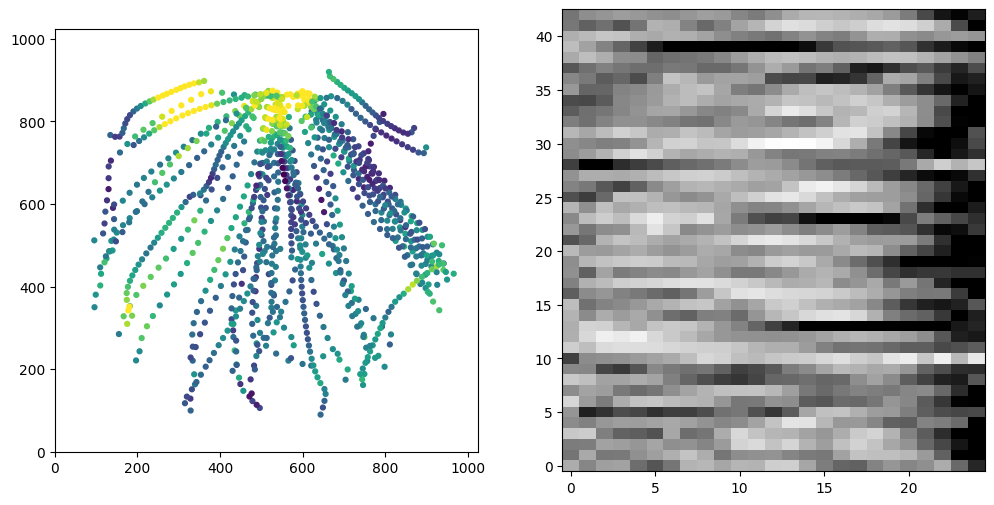

In [123]:
c = 0
n = 28
neural = ep_data["mat_num_cond"][c, n, :, :]   # shape: (trials, bins)
vmin = np.nanmin(neural)
vmax = np.nanpercentile(neural, 95)

plt.figure(figsize=(6, 6))
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

tr_tot = 0
for tr in range(x_matrix.shape[1]):
    x_tr = x_matrix[c, tr, :]
    y_tr = y_matrix[c, tr, :]
    a_tr = neural[tr, :]  # neural activity for same trial/bin points

    # keep only valid points across x, y, and activity
    m = (~np.isnan(x_tr)) & (~np.isnan(y_tr)) & (~np.isnan(a_tr))
    if not np.any(m):
        continue
    tr_tot += 1
    sc = axs[0].scatter(x_tr[m],y_tr[m],c=a_tr[m],s=12,cmap="viridis",vmin=vmin,vmax=vmax)

axs[0].set_ylim([0, 1024])
axs[0].set_xlim([0, 1024])
axs[0].set_aspect("equal", adjustable="box")
# axs[0].set_colorbar(sc, label="Neural activity")

axs[1].imshow(neural[:tr_tot,:], aspect='auto', origin='lower', cmap='gray_r', vmin = vmin, vmax = vmax,interpolation='none')
plt.show()

2016 0


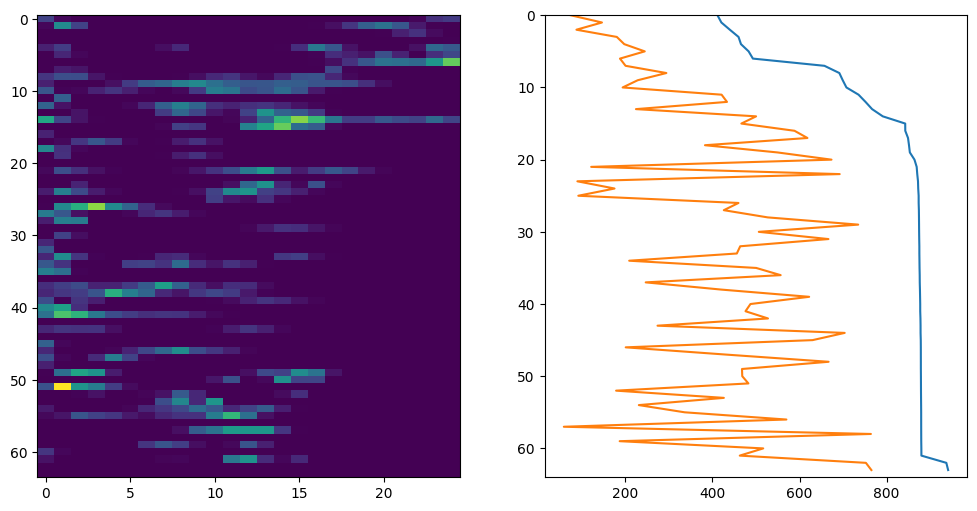

In [52]:
c = 1
n = 8
all_conditions = list(dict.fromkeys(conditions))
end_y = end_loc[np.array(conditions) == all_conditions[c], 1]
start_y = start_loc[np.array(conditions) == all_conditions[c], 1]
sort_by_end_y = np.argsort(end_y)
good_rows = np.where(np.sum(np.isnan(ep_data["mat_num_cond"][c,n,:,:]), axis = 1) != 25)[0][sort_by_end_y]
print(np.sum(good_rows), np.sum(conditions == all_conditions[c]))
fig, axs = plt.subplots(1, 2, figsize = (12, 6))
axs[0].imshow(ep_data["mat_num_cond"][c,n,:,:][good_rows,:], aspect = "auto", cmap = "viridis")
axs[1].plot(end_y[sort_by_end_y], np.arange(len(end_y)))
axs[1].plot(start_y[sort_by_end_y], np.arange(len(start_y)))
axs[1].set_ylim([0, len(end_y)])
axs[1].invert_yaxis()

2016 0


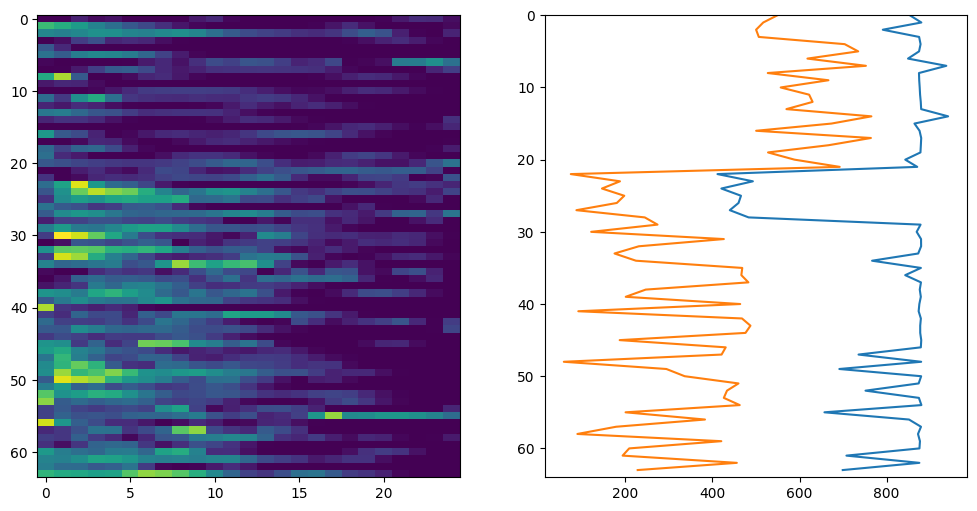

In [59]:
c = 1
n = 12
all_conditions = list(dict.fromkeys(conditions))
end_y = end_loc[np.array(conditions) == all_conditions[c], 1]
start_y = start_loc[np.array(conditions) == all_conditions[c], 1]
bottom = start_y > 500
top = end_y < 520
full = (bottom | top) == False
order = np.zeros(len(end_y))
order[bottom] = 1
order[top] = 2
order[full] = 3
sort_by_length = np.argsort(order)
good_rows = np.where(np.sum(np.isnan(ep_data["mat_num_cond"][c,n,:,:]), axis = 1) != 25)[0][sort_by_length]
print(np.sum(good_rows), np.sum(conditions == all_conditions[c]))
fig, axs = plt.subplots(1, 2, figsize = (12, 6))
axs[0].imshow(ep_data["mat_num_cond"][c,n,:,:][good_rows,:], aspect = "auto", cmap = "viridis")
axs[1].plot(end_y[sort_by_length], np.arange(len(end_y)))
axs[1].plot(start_y[sort_by_length], np.arange(len(start_y)))
axs[1].set_ylim([0, len(end_y)])
axs[1].invert_yaxis()